# Customer Churn Analysis

## Exploratory Data Analysis

This project analyzes telecom customer churn to identify customer segments, contract characteristics, and service attributes associated with higher churn.

### Business Objectives

- Measure the overall customer churn rate
- Identify high-risk customer segments
- Analyze churn by contract and internet service
- Evaluate support and security service patterns
- Analyze churn across customer tenure groups
- Translate analytical findings into retention recommendations


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 2. Load Dataset

The dataset is loaded using a relative file path so the notebook can run after cloning the GitHub repository.


In [2]:
df = pd.read_csv("Customer churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset Inspection

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 7,043
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Quality Assessment

The dataset is checked for missing values, complete-row duplicates, and duplicate customer identifiers.


In [5]:
print("Standard Missing Values:")
print(df.isnull().sum())

print("\nComplete Duplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Customer IDs:")
print(df["customerID"].duplicated().sum())

Standard Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Complete Duplicate Rows:
0

Duplicate Customer IDs:
0


### TotalCharges Data Cleaning

`TotalCharges` is stored as an object column because blank-string values exist in the source dataset.

The column is converted to numeric using `errors="coerce"` so invalid or blank values become missing values and can be investigated explicitly.


In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isna().sum())

df[df["TotalCharges"].isna()]

Missing TotalCharges after conversion:
11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


The missing `TotalCharges` records represent customers with zero tenure. Their total charges are set to 0 because they have not yet accumulated historical charges.


In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


### Senior Citizen Category Cleaning

In [8]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({
    1: "Yes",
    0: "No"
})

df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

## 5. Overall Customer Churn

In [9]:
total_customers = len(df)

churned_customers = (
    df["Churn"] == "Yes"
).sum()

retained_customers = (
    df["Churn"] == "No"
).sum()

churn_rate = (
    churned_customers / total_customers
) * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Retained Customers: {retained_customers:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 7,043
Churned Customers: 1,869
Retained Customers: 5,174
Overall Churn Rate: 26.54%


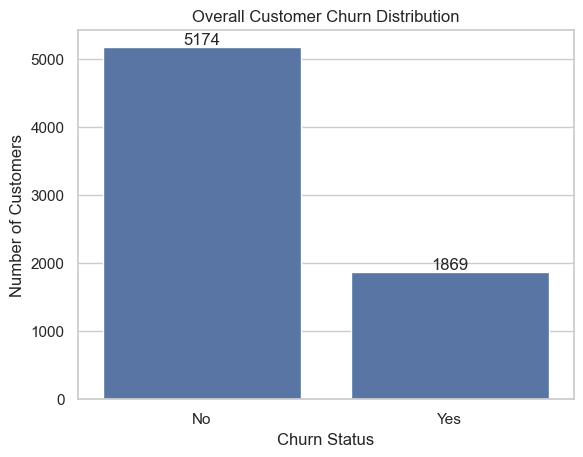

In [10]:
ax = sns.countplot(
    data=df,
    x="Churn"
)

ax.bar_label(ax.containers[0])

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

### Business Finding

Approximately 26.54% of customers churned. This means roughly one in four customers left the telecom provider, highlighting a significant customer retention opportunity.


## 6. Reusable Churn Rate Function

A reusable function is created to calculate churn percentages across customer segments.


In [11]:
def churn_rate_by(column):

    churn_rate = (
        df.groupby(column, observed=True)["Churn"]
        .apply(
            lambda x: (
                x == "Yes"
            ).mean() * 100
        )
        .round(2)
        .sort_values(ascending=False)
    )

    return churn_rate

## 7. Churn by Contract Type

In [12]:
contract_churn = churn_rate_by("Contract")

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

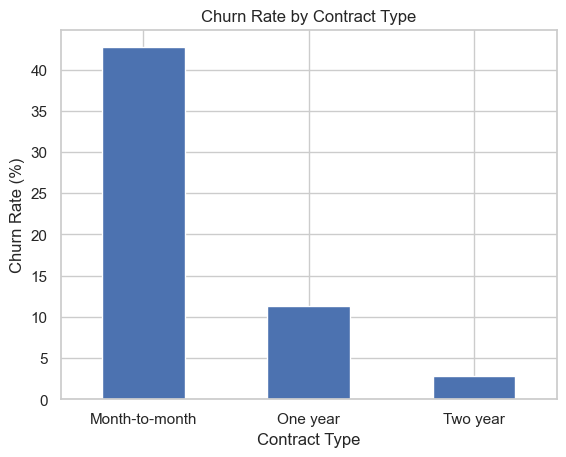

In [13]:
contract_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Business Finding

Month-to-month customers have the highest churn rate. Customers with one-year and two-year contracts demonstrate significantly stronger retention.

**Recommendation:** Prioritize month-to-month customers for loyalty campaigns and contract upgrade incentives.


## 8. Churn by Internet Service

In [14]:
internet_churn = churn_rate_by("InternetService")

internet_churn

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

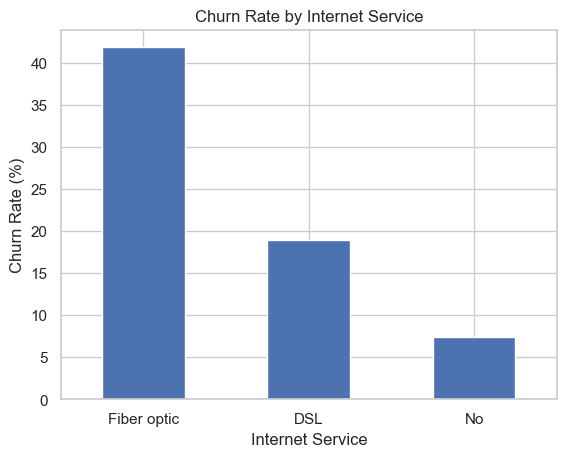

In [15]:
internet_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Business Finding

Fiber optic customers show the highest churn rate among internet service categories.

**Recommendation:** Investigate fiber optic pricing, service reliability, customer expectations, and technical support interactions.


## 9. Churn by Online Security

In [16]:
churn_rate_by("OnlineSecurity")

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

### Business Finding

Customers without Online Security demonstrate higher churn than customers subscribed to the service.

Online Security adoption can be used as a segmentation signal when identifying high-risk customers.


## 10. Churn by Technical Support

In [17]:
churn_rate_by("TechSupport")

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

### Business Finding

Customers without Technical Support demonstrate substantially higher churn.

**Recommendation:** Proactive technical support programs may improve customer retention.


## 11. Telecom Service Attribute Analysis

In [18]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for column in service_columns:

    print(f"\nChurn Rate by {column}")

    print(
        churn_rate_by(column)
    )


Churn Rate by PhoneService
PhoneService
Yes    26.71
No     24.93
Name: Churn, dtype: float64

Churn Rate by MultipleLines
MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn, dtype: float64

Churn Rate by InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

Churn Rate by OnlineSecurity
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by DeviceProtection
DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by TechSupport
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn,

## 12. Customer Tenure Segmentation

Customer tenure is grouped into lifecycle segments to compare churn risk across customer maturity levels.


In [19]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

tenure_churn = churn_rate_by("TenureGroup")

tenure_churn

TenureGroup
0-12 Months     47.44
13-24 Months    28.71
25-48 Months    20.39
49-72 Months     9.51
Name: Churn, dtype: float64

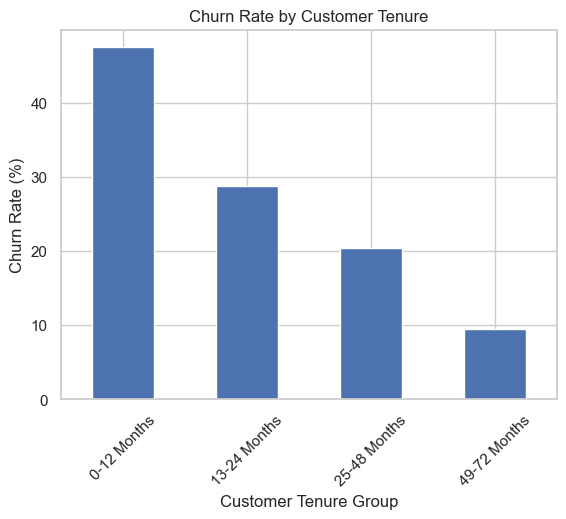

In [20]:
tenure_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Business Finding

Short-tenure customers demonstrate greater churn vulnerability.

The first year of the customer lifecycle represents a critical retention period.

**Recommendation:** Implement stronger onboarding, proactive support, and early engagement programs for newly acquired customers.


## 13. Payment Method Analysis

In [21]:
payment_churn = churn_rate_by("PaymentMethod")

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

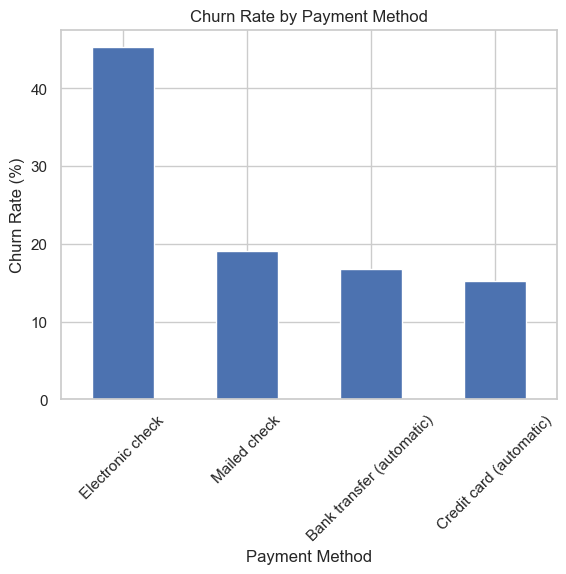

In [22]:
payment_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 14. Key Churn Indicators Identified

The exploratory analysis identified the following important churn segmentation factors:

1. Month-to-month contracts
2. Fiber optic internet service
3. Low customer tenure
4. Absence of Online Security
5. Absence of Technical Support
6. Service bundle and support gaps

These findings represent associations observed during exploratory analysis and should not be interpreted as causal relationships.


## 15. Business Recommendations

Based on the exploratory analysis:

- Prioritize month-to-month customers in retention campaigns.
- Encourage annual contract adoption through loyalty incentives.
- Investigate the elevated churn among fiber optic customers.
- Develop an early-tenure customer retention program.
- Provide proactive technical support to high-risk customers.
- Promote relevant Online Security and support service bundles.
- Use the identified churn indicators as candidate features for a future churn prediction model.


## Conclusion

The analysis demonstrates that contract type, internet service, customer tenure, Online Security, and Technical Support are important churn segmentation factors.

The strongest retention opportunity is to focus on short-tenure, month-to-month customers and investigate the elevated churn observed among fiber optic subscribers.

This project demonstrates how exploratory data analysis can translate customer-level telecom data into actionable customer retention insights.
